In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [218]:
df = pd.read_csv('.\data\data_encuesta.csv', sep=';')

df = df.drop("user_id", axis=1)

df.head()

,time_minutes,total_time(minutes)
0,30,180
1,45,180
2,40,120
3,15,120
4,35,600


In [219]:
df.shape

(32, 2)

In [220]:
df.describe()

,time_minutes,total_time(minutes)
count,32.000000,32.000000
mean,31.875000,151.875000
std,12.422015,143.761395
min,10.000000,60.000000
25%,22.500000,60.000000
50%,30.000000,90.000000
75%,40.000000,180.000000
max,50.000000,600.000000


In [221]:
mean = df.mean()
cov = df.cov()

rng = np.random.default_rng(seed=42)

sintectico = rng.multivariate_normal(mean, cov, size = 1500)
df_sintectico = pd.DataFrame(sintectico, columns=df.columns)

df_sintectico['time_minutes'] = round(df_sintectico['time_minutes'])
df_sintectico['total_time(minutes)'] = round(df_sintectico['total_time(minutes)'])
df_sintectico = df_sintectico[(df_sintectico > 0).all(axis=1)]
df_sintectico = df_sintectico[df_sintectico['total_time(minutes)'] >= 10]
df_sintectico = df_sintectico[df_sintectico['time_minutes'] >= 10]
df_sintectico = df_sintectico[df_sintectico['time_minutes'] < df_sintectico['total_time(minutes)']]

display(df_sintectico)

,time_minutes,total_time(minutes)
0,21.0,196.0
1,46.0,259.0
3,29.0,170.0
4,22.0,150.0
5,45.0,278.0
...,...,...
1494,49.0,183.0
1495,54.0,243.0
1496,60.0,143.0
1497,21.0,82.0


In [222]:
df_sintectico.describe()

,time_minutes,total_time(minutes)
count,1148.000000,1148.000000
mean,33.994774,200.764808
std,11.406799,108.959878
min,10.000000,19.000000
25%,26.000000,117.000000
50%,34.000000,187.000000
75%,42.000000,269.000000
max,74.000000,609.000000


In [223]:
df_union = pd.concat([df, df_sintectico])
df_union.head()

,time_minutes,total_time(minutes)
0,30.0,180.0
1,45.0,180.0
2,40.0,120.0
3,15.0,120.0
4,35.0,600.0


In [224]:
df_union.shape

display(df_union)

df_union.to_csv("datos.csv")

,time_minutes,total_time(minutes)
0,30.0,180.0
1,45.0,180.0
2,40.0,120.0
3,15.0,120.0
4,35.0,600.0
...,...,...
1494,49.0,183.0
1495,54.0,243.0
1496,60.0,143.0
1497,21.0,82.0


In [225]:
df_union.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1494     True
1495    False
1496    False
1497    False
1499    False
Length: 1180, dtype: bool

In [226]:
df_union.shape

(1180, 2)

In [227]:
df_union = df_union.sample(frac=1).reset_index(drop=True)

In [228]:

from sklearn.model_selection import train_test_split

train, test = train_test_split(df_union, test_size=0.2, random_state=42)

In [229]:
train.shape

(944, 2)

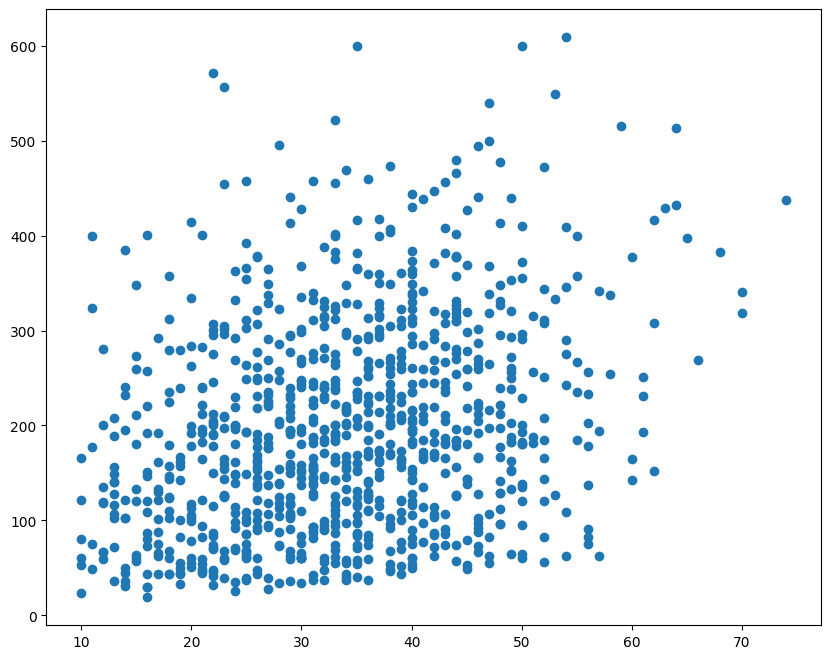

In [230]:
plt.figure(figsize=(10,8))
plt.scatter(train['time_minutes'], train['total_time(minutes)'])
plt.show()

In [231]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Valor de silueta para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Silueta')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Método del codo para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Suma de la distancia al cuadrado')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

Training model for K=2
Training model for K=3


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=4
Training model for K=5


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=6
Training model for K=7


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=8
Training model for K=9


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=10


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


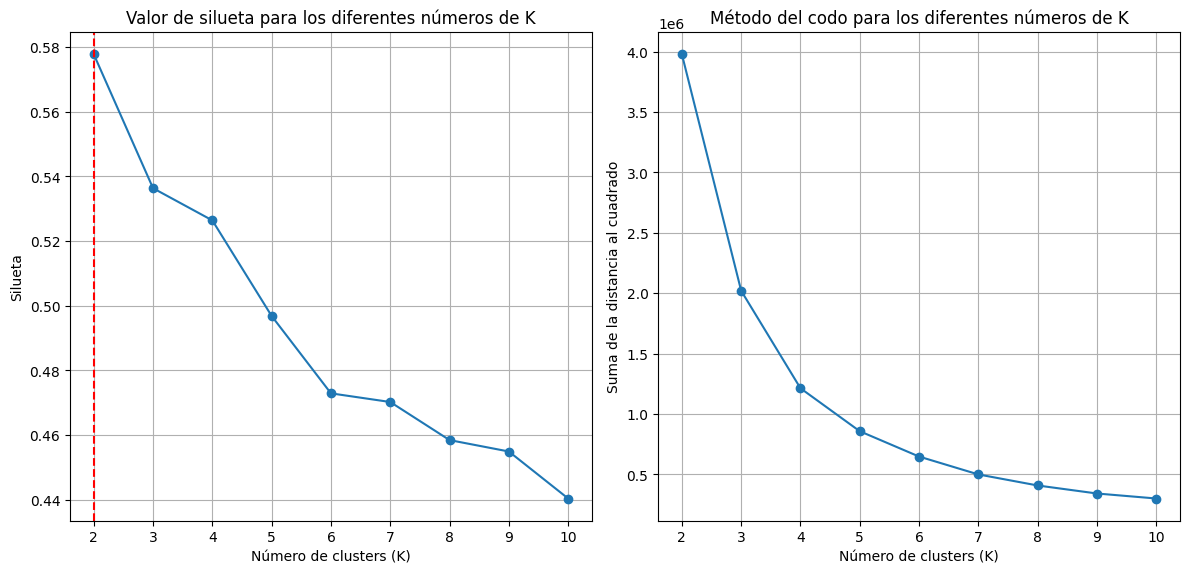

Optimal number of clusters: 2


2

In [232]:
find_optimal_k(train)

In [233]:
from sklearn.cluster import KMeans
K = 4

kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )

kmeans_model.fit(train)

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [234]:
cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

print(cluster_centers)

[[ 40.02222222 425.57777778]
 [ 29.89032258  82.98709677]
 [ 34.01538462 183.85846154]
 [ 36.70319635 289.07305936]]


In [235]:
cluster_centers = cluster_centers[np.argsort(cluster_centers[:, 0])]

print(cluster_centers)

[[ 29.89032258  82.98709677]
 [ 34.01538462 183.85846154]
 [ 36.70319635 289.07305936]
 [ 40.02222222 425.57777778]]


In [236]:
def reorder_labels(labels, data, col='time_minutes'):
    """Reetiqueta los clusters de CUALQUIER algoritmo según el orden ascendente
    de la media de `col`, de forma que la etiqueta k signifique siempre lo mismo
    (mismo rango de valores) y los resultados sean comparables entre algoritmos.

    Devuelve (new_labels, centers) donde centers[k] es el centroide real
    (media de las columnas) de los puntos con new_labels == k.
    """
    labels = np.asarray(labels)
    means = pd.Series(np.asarray(data[col]), index=np.arange(len(labels))).groupby(labels).mean()
    order = means.sort_values().index.to_numpy()
    remap = {old: new for new, old in enumerate(order)}
    new_labels = np.vectorize(remap.get)(labels)
    centers = np.array([
        data.to_numpy()[new_labels == k].mean(axis=0) for k in range(len(order))
    ])
    return new_labels, centers

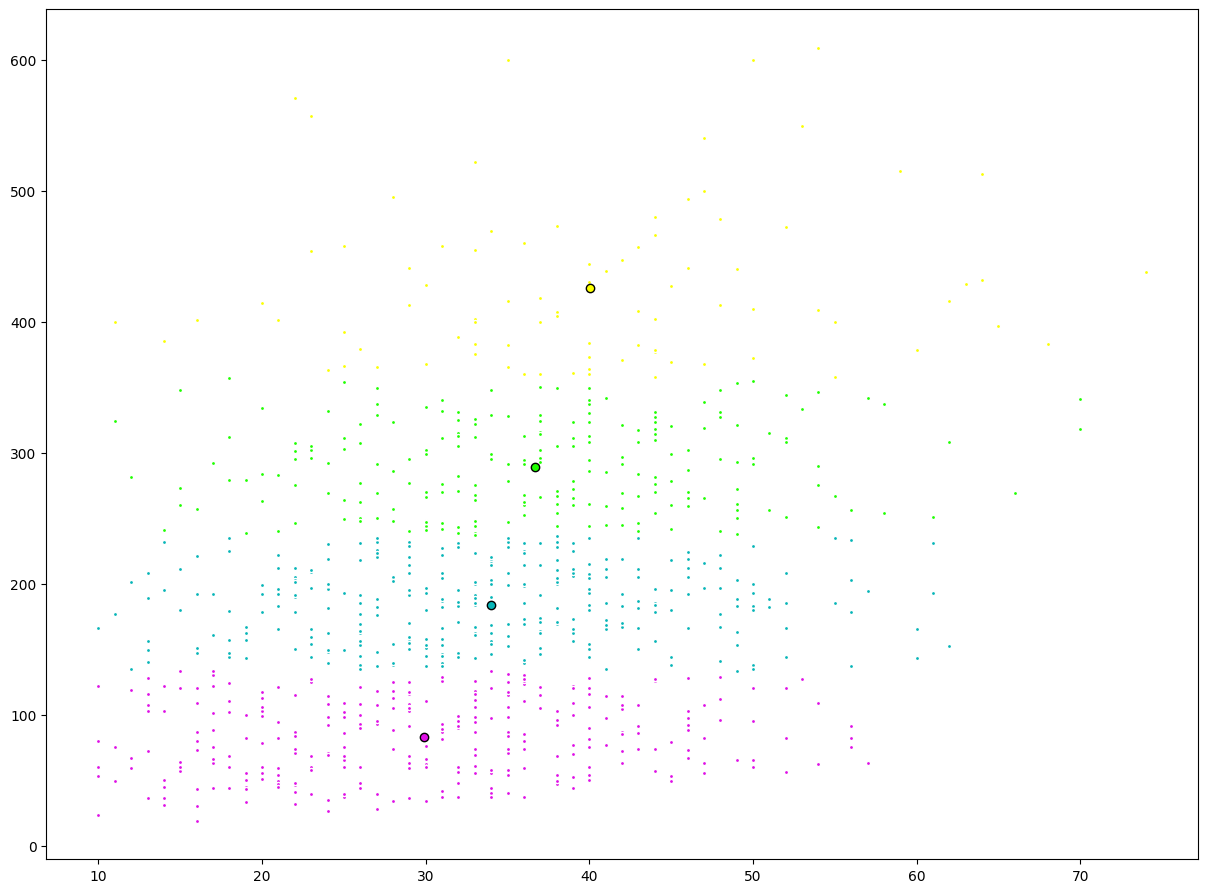

In [237]:
cluster_labels, cluster_centers = reorder_labels(cluster_labels, train)
fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members = cluster_labels == k
    cluster_center = cluster_centers[k]
    plt.plot(train.iloc[my_members, 0], train.iloc[my_members, 1], "w", markerfacecolor=col, marker=".")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

In [238]:
from sklearn.cluster import MiniBatchKMeans
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k_mini(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = MiniBatchKMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Valor de silueta para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Silueta')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Método del codo para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Suma de la distancia al cuadrado')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

Training model for K=2


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=3
Training model for K=4


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=5
Training model for K=6


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=7


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=8


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=9


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=10


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


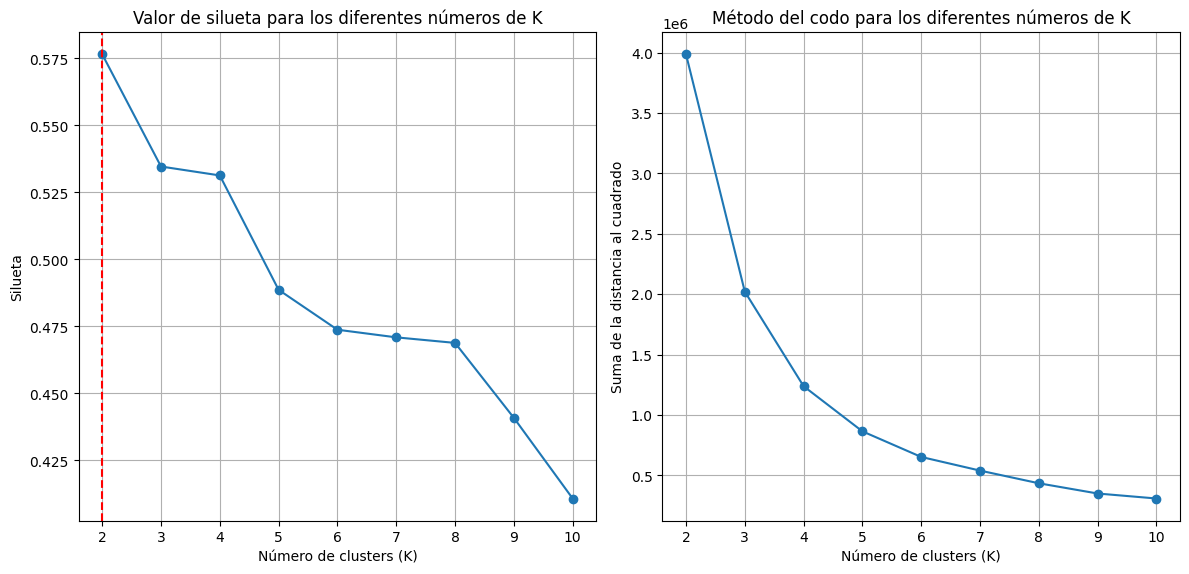

Optimal number of clusters: 2


2

In [239]:
find_optimal_k_mini(train)

In [240]:

minikmeans_model = MiniBatchKMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            random_state=42
            )

minikmeans_model.fit(train)

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,10


In [241]:
mincluster_labels = minikmeans_model.labels_
mincluster_centers = minikmeans_model.cluster_centers_

print(mincluster_centers)

[[ 37.31437885 310.48152843]
 [ 29.91858367  85.58581416]
 [ 34.19747767 193.9887546 ]
 [ 40.81617183 452.15476943]]


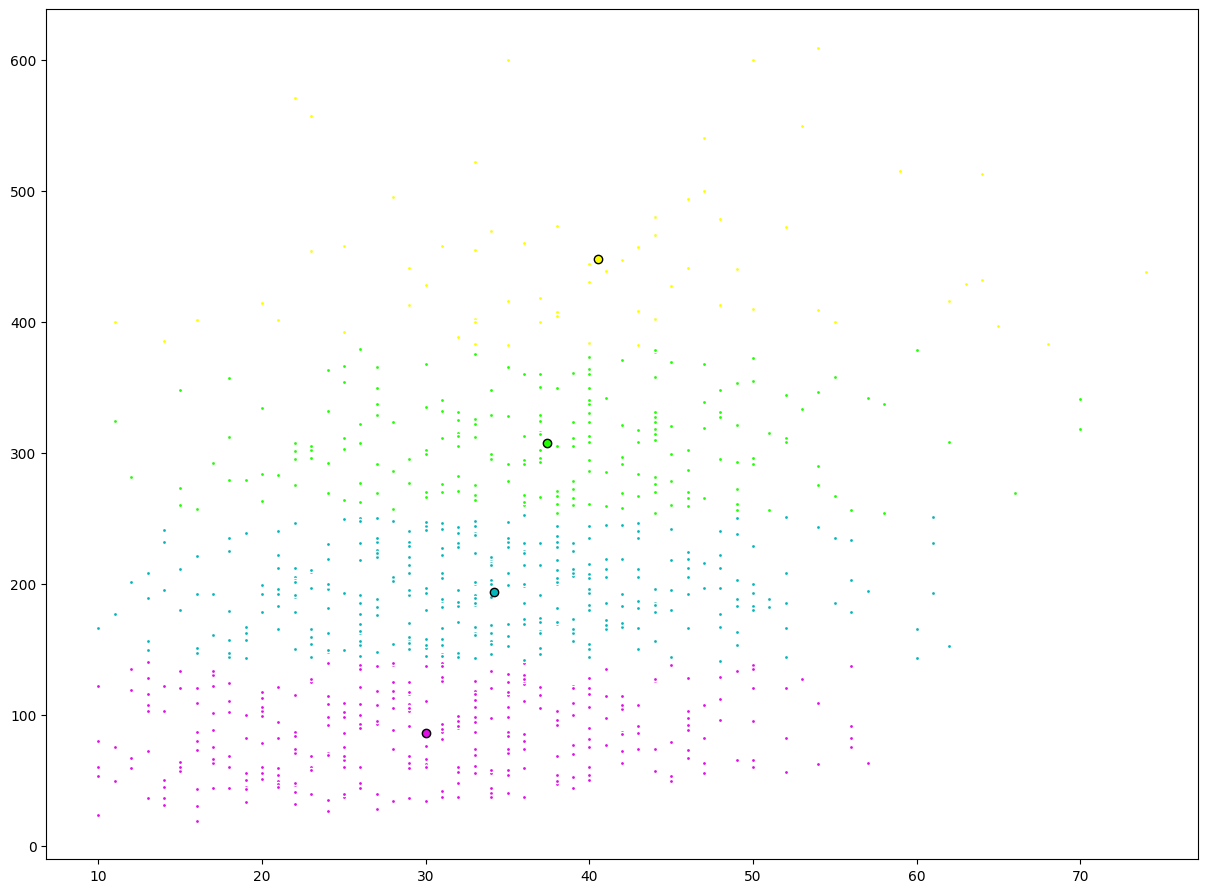

In [242]:
mincluster_labels = minikmeans_model.predict(train)

mincluster_labels, mincluster_centers = reorder_labels(mincluster_labels, train)

fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members = mincluster_labels == k
    cluster_center = mincluster_centers[k]
    plt.plot(train.iloc[my_members, 0], train.iloc[my_members, 1], "w", markerfacecolor=col, marker=".")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

In [243]:

for i in range(14):
    for _, data in test.iterrows():
        minikmeans_model._counts[:] = 18
        minikmeans_model.partial_fit(data.values.reshape(1, -1))
    

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with f

In [244]:
mincluster_labels = minikmeans_model.labels_
mincluster_centers = minikmeans_model.cluster_centers_

print(mincluster_centers)

[[ 36.42678667 276.9779628 ]
 [ 30.61111787  83.99070828]
 [ 33.2625925  168.6818324 ]
 [ 43.48782116 428.75997752]]


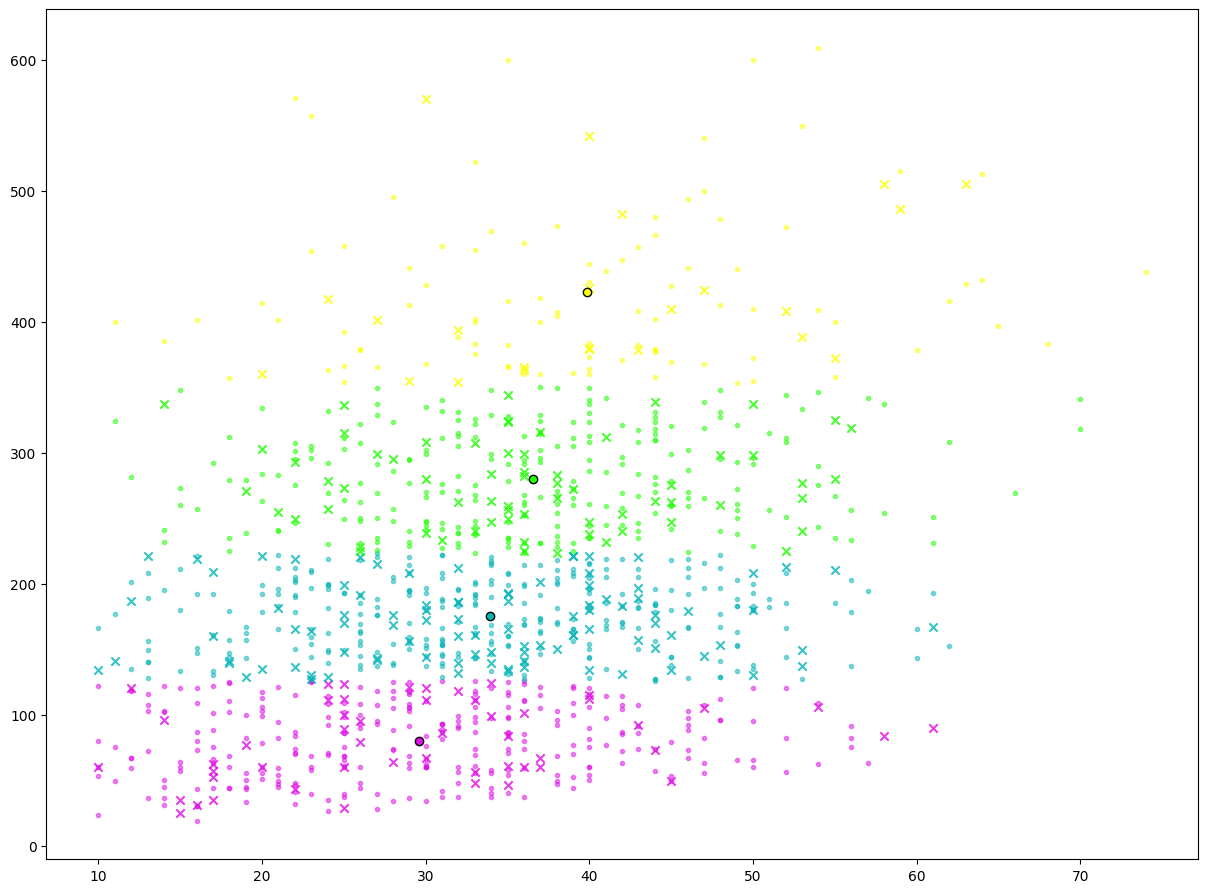

In [245]:
label_train = minikmeans_model.predict(train)
label_test = minikmeans_model.predict(test)

mincluster_labels, mincluster_centers = reorder_labels(label_train, train)
mincluster_label_test, mincluster_centers_test = reorder_labels(label_test, test)

fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members_train = mincluster_labels == k 
    my_members_test = mincluster_label_test == k
    cluster_center = mincluster_centers[k]
    plt.scatter(train.iloc[my_members_train, 0], train.iloc[my_members_train, 1], alpha = 0.5, color=col, marker=".")
    plt.scatter(test.iloc[my_members_test, 0], test.iloc[my_members_test, 1],  alpha = 0.8, color=col, marker="x")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

Centros KMeans (ordenados por time_minutes):
 [[ 29.89032258  82.98709677]
 [ 34.01538462 183.85846154]
 [ 36.70319635 289.07305936]
 [ 40.02222222 425.57777778]]
Centros MiniBatchKMeans (ordenados por time_minutes):
 [[ 29.59589041  80.15068493]
 [ 33.8990228  175.17915309]
 [ 36.52589641 279.61752988]
 [ 39.82978723 422.56382979]]


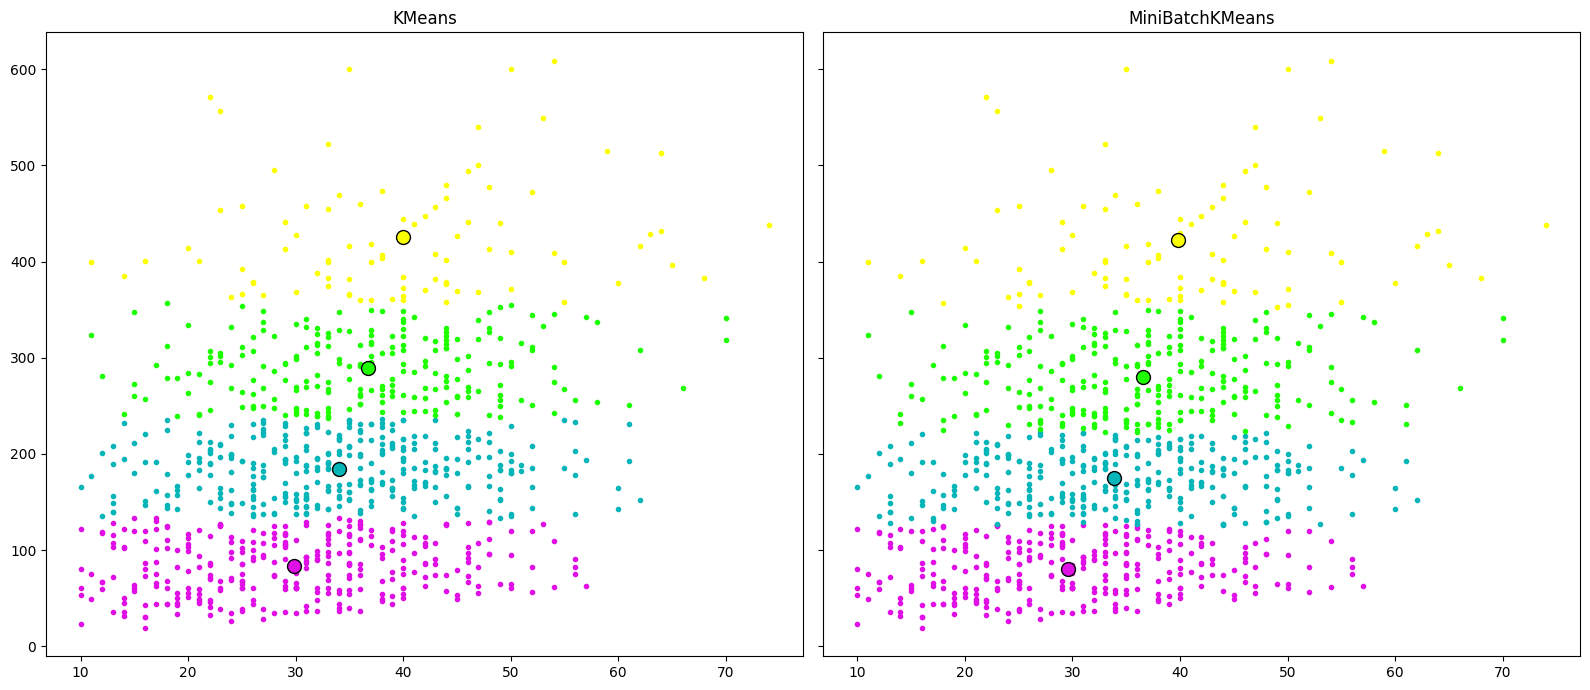

In [246]:
print("Centros KMeans (ordenados por time_minutes):\n", cluster_centers)
print("Centros MiniBatchKMeans (ordenados por time_minutes):\n", mincluster_centers)

colors = ["#DF0FE6", "#06B5B8", "#1EFF00", "#FBFF00"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for k, col in zip(range(4), colors):
    axes[0].scatter(train.iloc[cluster_labels == k, 0], train.iloc[cluster_labels == k, 1], color=col, marker=".")
    axes[0].scatter(cluster_centers[k, 0], cluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[0].set_title("KMeans")

for k, col in zip(range(4), colors):
    axes[1].scatter(train.iloc[mincluster_labels == k, 0], train.iloc[mincluster_labels == k, 1], color=col, marker=".")
    axes[1].scatter(mincluster_centers[k, 0], mincluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[1].set_title("MiniBatchKMeans")

plt.tight_layout()
plt.show()

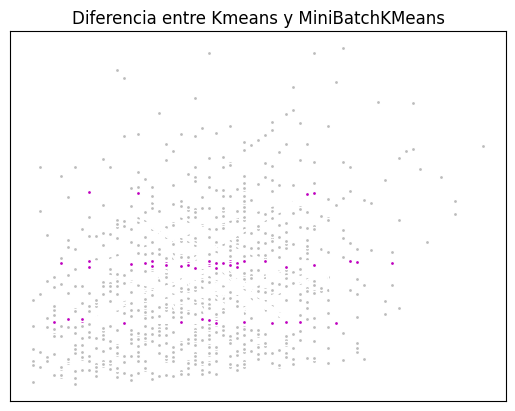

In [247]:
different = cluster_labels != mincluster_labels
    
identical = np.logical_not(different)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different, 0], train.iloc[different, 1], "w", markerfacecolor="m", marker=".")
plt.title("Diferencia entre Kmeans y MiniBatchKMeans")
plt.xticks(())
plt.yticks(())

plt.show()

In [248]:
print("Centros KMeans (originales):")
for i, c in enumerate(cluster_centers):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros MiniBatch (actuales):")
for i, c in enumerate(mincluster_centers):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print(f"¿Cuántos marcados como 'different'?: {different.sum()} de {len(mincluster_labels)}")


Centros KMeans (originales):
  KM 0: total_time=83.0
  KM 1: total_time=183.9
  KM 2: total_time=289.1
  KM 3: total_time=425.6

Centros MiniBatch (actuales):
  MBK 0: total_time=80.2
  MBK 1: total_time=175.2
  MBK 2: total_time=279.6
  MBK 3: total_time=422.6
¿Cuántos marcados como 'different'?: 58 de 944


# JERARQUÍAS

In [249]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [250]:
modelHierarchy = AgglomerativeClustering(n_clusters = 4)

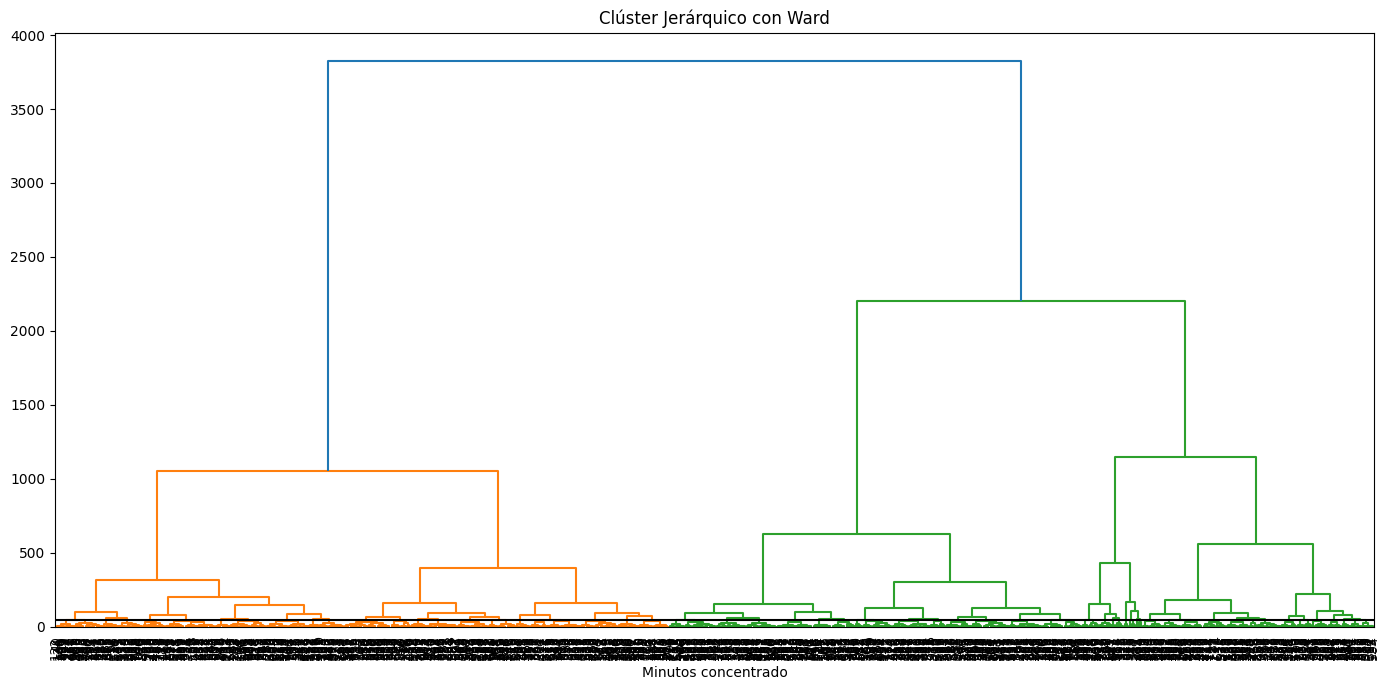

In [251]:
modelHierarchy = modelHierarchy.fit(train)
Z = linkage(train, method='ward')

plt.figure(figsize=(14, 7))
plt.title('Clúster Jerárquico con Ward')
dendrogram(
    Z,
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
)
plt.xlabel("Minutos concentrado")
plt.axhline(y=45, c='k')
plt.tight_layout()
plt.show()

Centros KMeans (ordenados por time_minutes):
 [[ 29.89032258  82.98709677]
 [ 34.01538462 183.85846154]
 [ 36.70319635 289.07305936]
 [ 40.02222222 425.57777778]]
Centros Agglomerative Ward (ordenados por time_minutes):
 [[ 30.87045455 104.04772727]
 [ 34.8        222.0440678 ]
 [ 37.36746988 334.21084337]
 [ 44.39534884 472.69767442]]


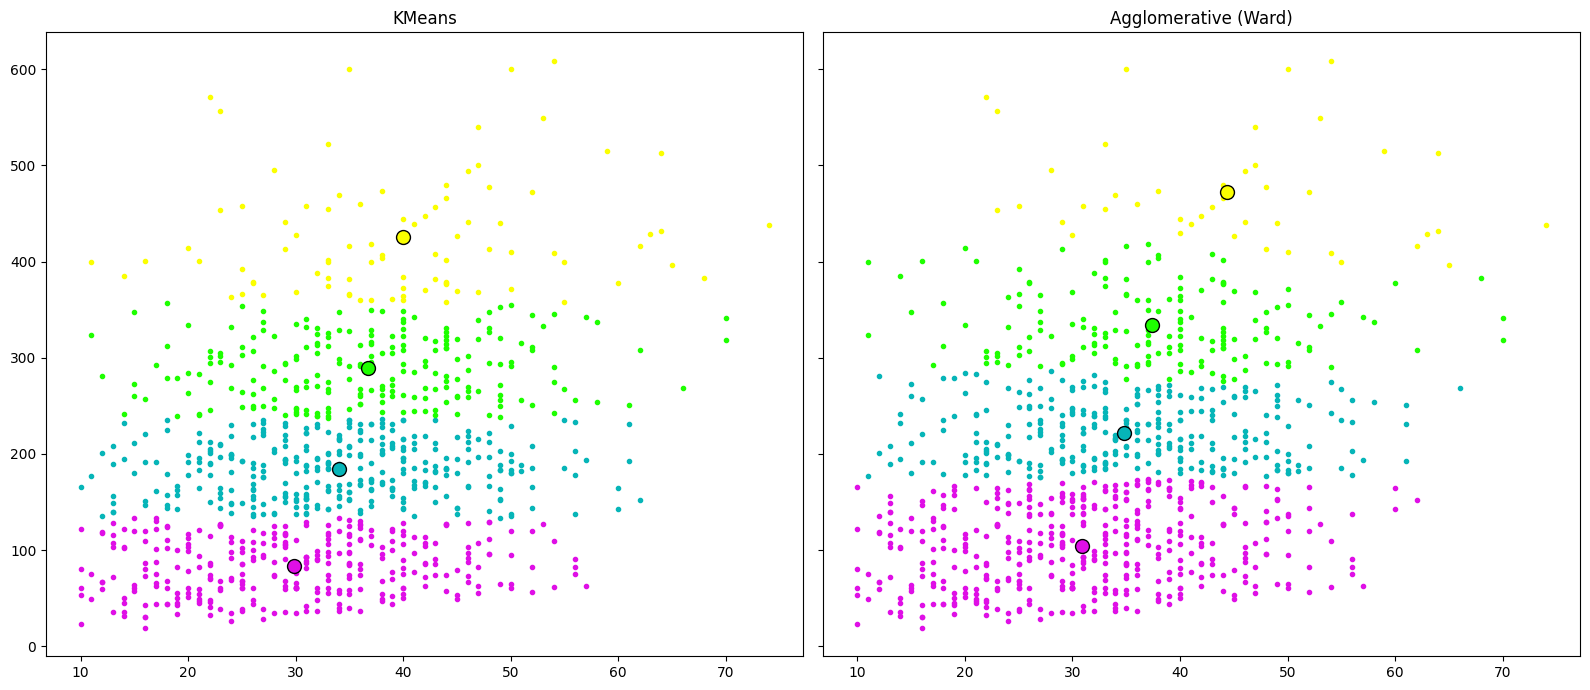

In [252]:
ward_labels, ward_centers = reorder_labels(modelHierarchy.labels_, train)

print("Centros KMeans (ordenados por time_minutes):\n", cluster_centers)
print("Centros Agglomerative Ward (ordenados por time_minutes):\n", ward_centers)

colors = ["#DF0FE6", "#06B5B8", "#1EFF00", "#FBFF00"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for k, col in zip(range(4), colors):
    axes[0].scatter(train.iloc[cluster_labels == k, 0], train.iloc[cluster_labels == k, 1], color=col, marker=".")
    axes[0].scatter(cluster_centers[k, 0], cluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[0].set_title("KMeans")

for k, col in zip(range(4), colors):
    axes[1].scatter(train.iloc[ward_labels == k, 0], train.iloc[ward_labels == k, 1], color=col, marker=".")
    axes[1].scatter(ward_centers[k, 0], ward_centers[k, 1], color=col, edgecolor="k", s=100)
axes[1].set_title("Agglomerative (Ward)")

plt.tight_layout()
plt.show()

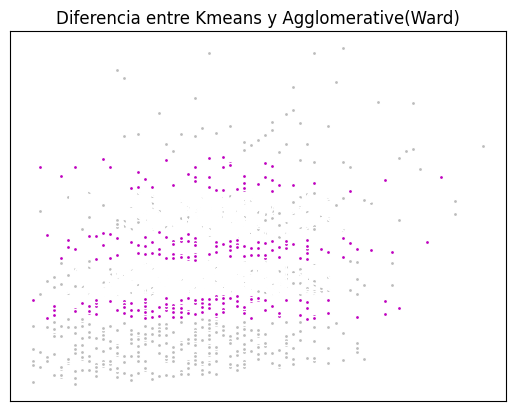

In [253]:
different_algorithms = cluster_labels != ward_labels
    
identical = np.logical_not(different_algorithms)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different_algorithms, 0], train.iloc[different_algorithms, 1], "w", markerfacecolor="m", marker=".")
plt.title("Diferencia entre Kmeans y Agglomerative(Ward)")
plt.xticks(())
plt.yticks(())

plt.show()

In [254]:
print("Centros KMeans (originales):")
for i, c in enumerate(cluster_centers):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros Aglomerative(Ward):")
for i, c in enumerate(ward_centers):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print(f"¿Cuántos marcados como 'different'?: {different_algorithms.sum()} de {len(cluster_labels)}")


Centros KMeans (originales):
  KM 0: total_time=83.0
  KM 1: total_time=183.9
  KM 2: total_time=289.1
  KM 3: total_time=425.6

Centros Aglomerative(Ward):
  MBK 0: total_time=104.0
  MBK 1: total_time=222.0
  MBK 2: total_time=334.2
  MBK 3: total_time=472.7
¿Cuántos marcados como 'different'?: 277 de 944


Centros MiniBatchKMeans (ordenados por time_minutes):
 [[ 29.59589041  80.15068493]
 [ 33.8990228  175.17915309]
 [ 36.52589641 279.61752988]
 [ 39.82978723 422.56382979]]
Centros Agglomerative Ward (ordenados por time_minutes):
 [[ 30.87045455 104.04772727]
 [ 34.8        222.0440678 ]
 [ 37.36746988 334.21084337]
 [ 44.39534884 472.69767442]]


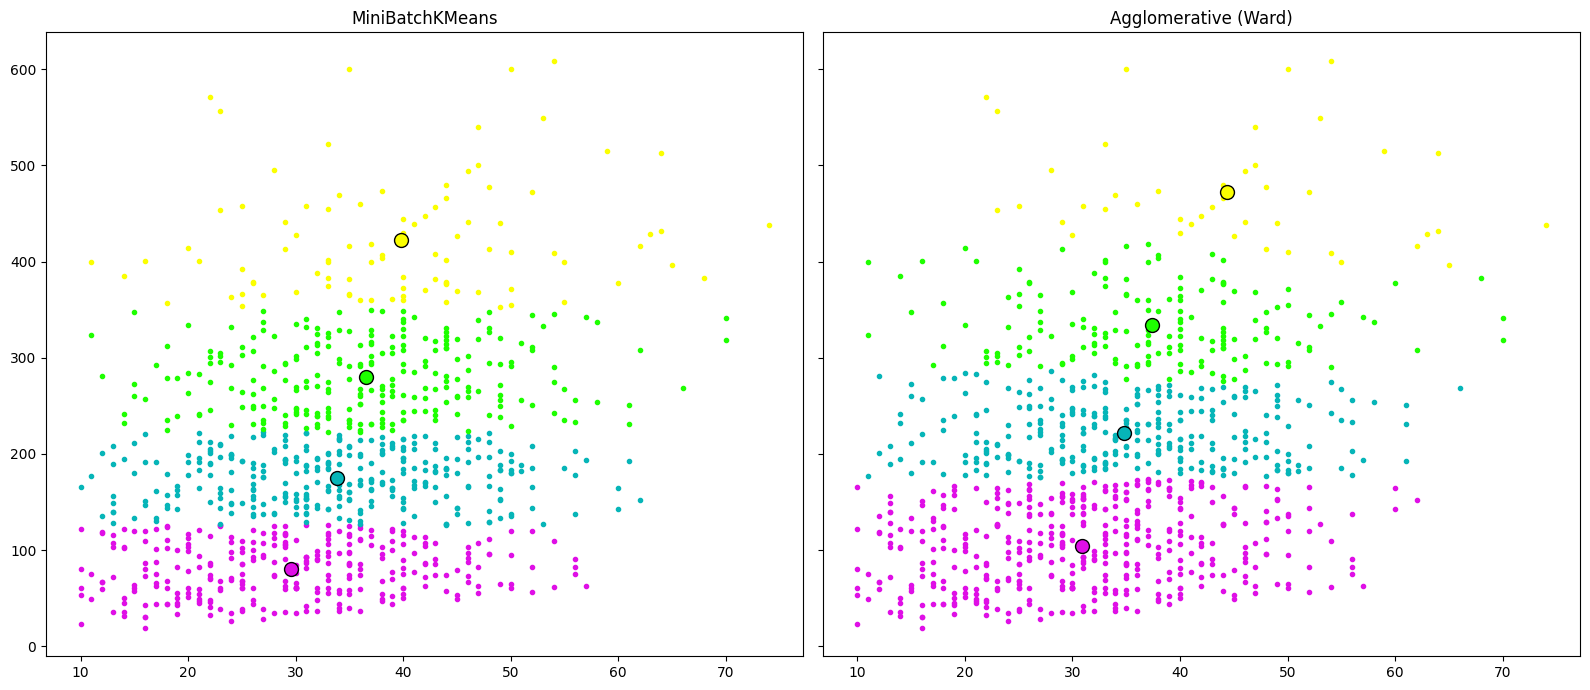

In [255]:
print("Centros MiniBatchKMeans (ordenados por time_minutes):\n", mincluster_centers)
print("Centros Agglomerative Ward (ordenados por time_minutes):\n", ward_centers)

colors = ["#DF0FE6", "#06B5B8", "#1EFF00", "#FBFF00"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for k, col in zip(range(4), colors):
    axes[0].scatter(train.iloc[mincluster_labels == k, 0], train.iloc[mincluster_labels == k, 1], color=col, marker=".")
    axes[0].scatter(mincluster_centers[k, 0], mincluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[0].set_title("MiniBatchKMeans")

for k, col in zip(range(4), colors):
    axes[1].scatter(train.iloc[ward_labels == k, 0], train.iloc[ward_labels == k, 1], color=col, marker=".")
    axes[1].scatter(ward_centers[k, 0], ward_centers[k, 1], color=col, edgecolor="k", s=100)
axes[1].set_title("Agglomerative (Ward)")

plt.tight_layout()
plt.show()

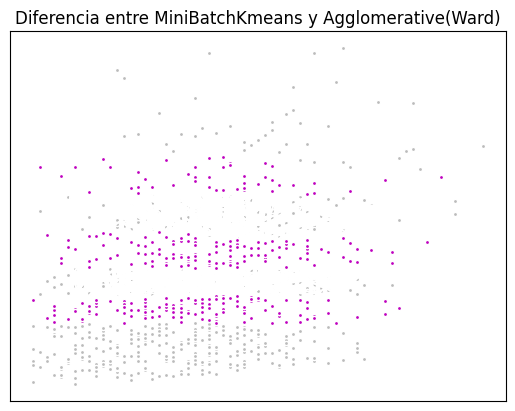

In [256]:
different_algorithms = mincluster_labels != ward_labels
    
identical = np.logical_not(different_algorithms)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different_algorithms, 0], train.iloc[different_algorithms, 1], "w", markerfacecolor="m", marker=".")
plt.title("Diferencia entre MiniBatchKmeans y Agglomerative(Ward)")
plt.xticks(())
plt.yticks(())

plt.show()

In [257]:
print("Centros MiniBatchKMeans:")
for i, c in enumerate(mincluster_centers):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros Aglomerative(Ward):")
for i, c in enumerate(ward_centers):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print(f"¿Cuántos marcados como 'different'?: {different_algorithms.sum()} de {len(mincluster_labels)}")


Centros MiniBatchKMeans:
  KM 0: total_time=80.2
  KM 1: total_time=175.2
  KM 2: total_time=279.6
  KM 3: total_time=422.6

Centros Aglomerative(Ward):
  MBK 0: total_time=104.0
  MBK 1: total_time=222.0
  MBK 2: total_time=334.2
  MBK 3: total_time=472.7
¿Cuántos marcados como 'different'?: 335 de 944


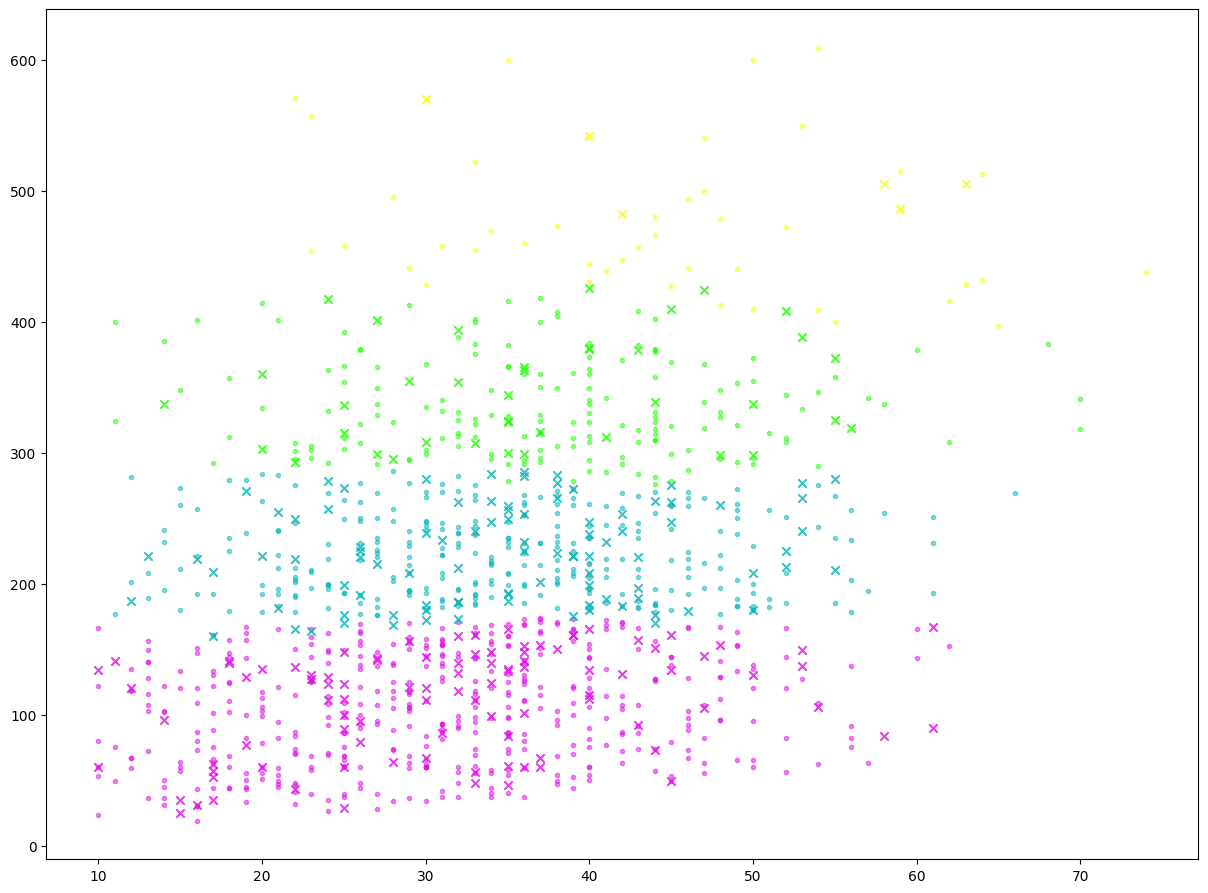

In [258]:
y_pred_ward = modelHierarchy.labels_.astype(int)
y_pred_test_ward = modelHierarchy.fit_predict(test)

ward_labels_test, ward_centers_test = reorder_labels(y_pred_test_ward, test)

fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members_train = ward_labels == k 
    my_members_test = ward_labels_test == k
    plt.scatter(train.iloc[my_members_train, 0], train.iloc[my_members_train, 1], alpha = 0.5, color=col, marker=".")
    plt.scatter(test.iloc[my_members_test, 0], test.iloc[my_members_test, 1],  alpha = 0.8, color=col, marker="x")

plt.show()

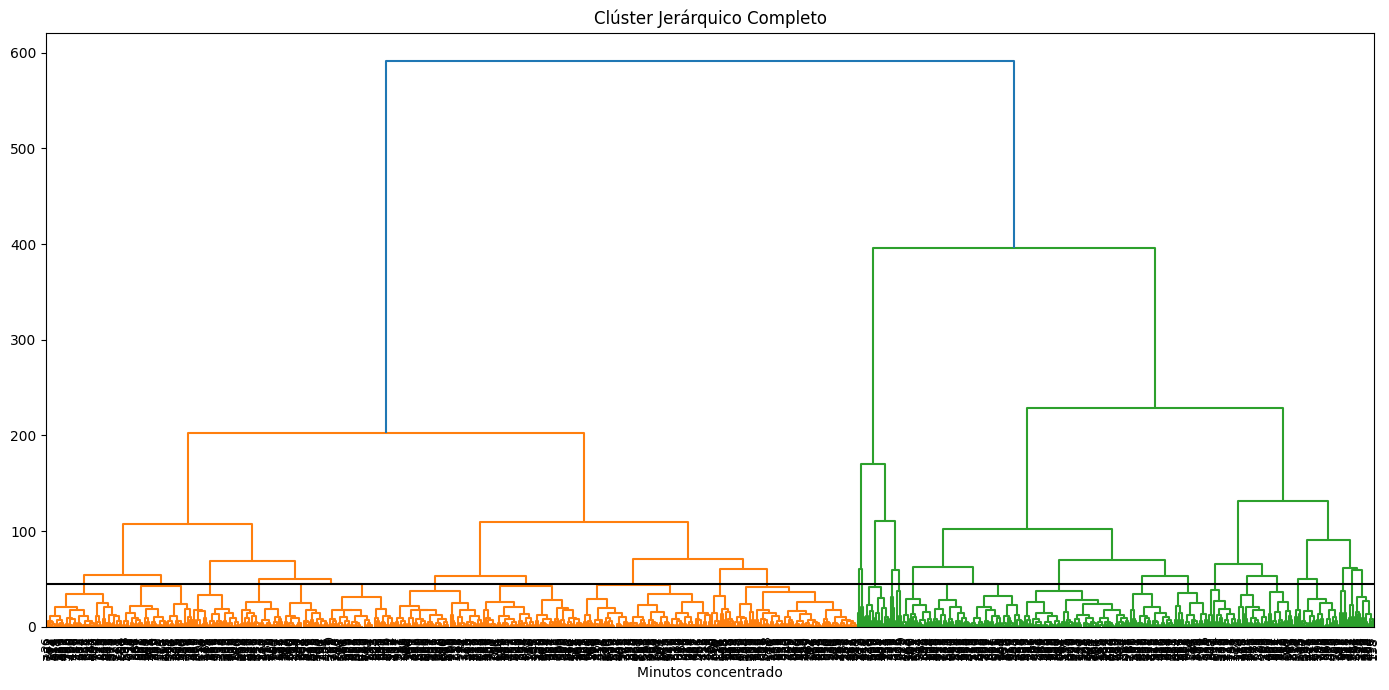

In [259]:
modelHier2 = AgglomerativeClustering(n_clusters=4, linkage='complete').fit(train)
Z = linkage(train, method='complete')

plt.figure(figsize=(14, 7))
plt.title('Clúster Jerárquico Completo')
dendrogram(
    Z,
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
)
plt.xlabel("Minutos concentrado")
plt.axhline(y=45, c='k')
plt.tight_layout()
plt.show()

Centros KMeans (ordenados por time_minutes):
 [[ 29.89032258  82.98709677]
 [ 34.01538462 183.85846154]
 [ 36.70319635 289.07305936]
 [ 40.02222222 425.57777778]]
Centros Agglomerative complete (ordenados por time_minutes):
 [[ 31.7677643  125.44020797]
 [ 35.13761468 260.64220183]
 [ 39.93220339 360.95762712]
 [ 40.61290323 493.4516129 ]]


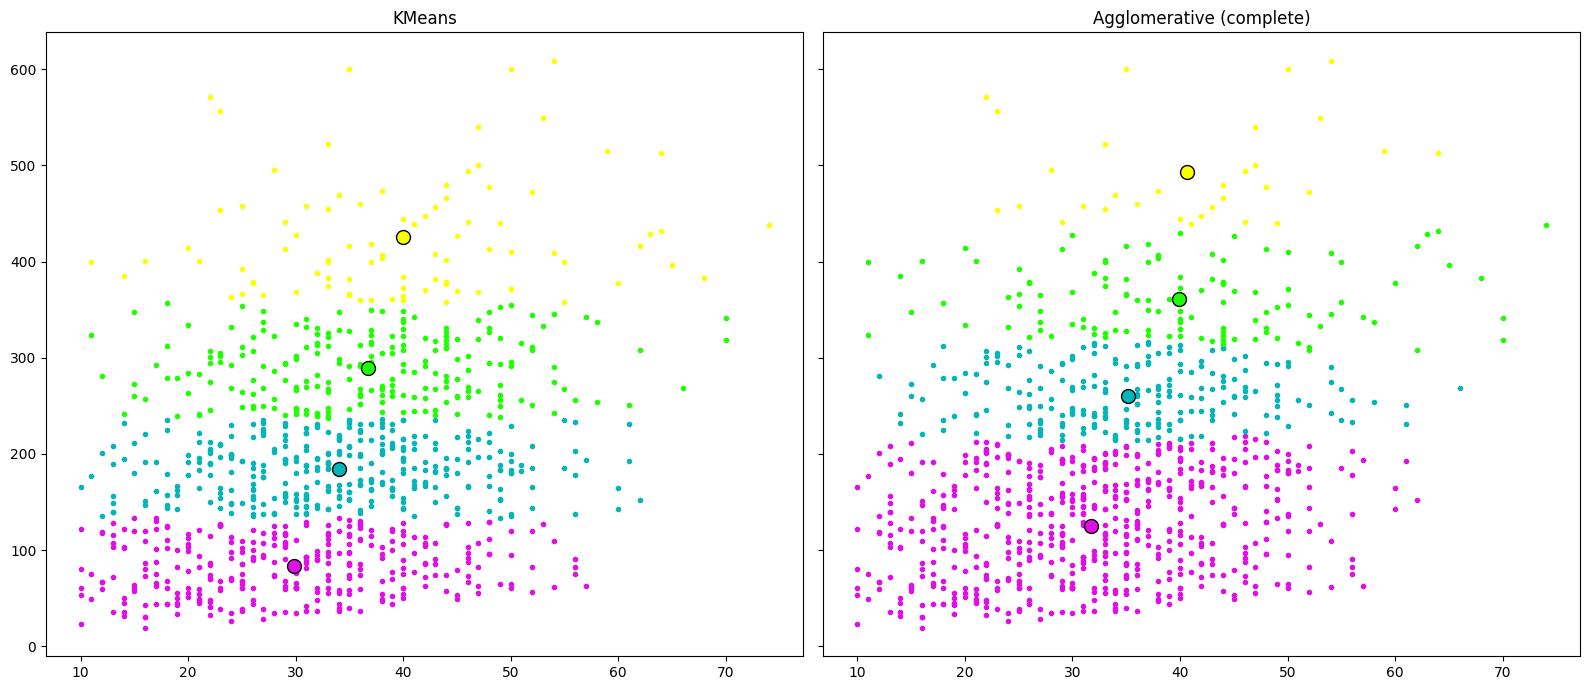

In [260]:
complete_labels, complete_centers = reorder_labels(modelHier2.labels_, train)

print("Centros KMeans (ordenados por time_minutes):\n", cluster_centers)
print("Centros Agglomerative complete (ordenados por time_minutes):\n", complete_centers)

colors = ["#DF0FE6", "#06B5B8", "#1EFF00", "#FBFF00"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for k, col in zip(range(4), colors):
    axes[0].scatter(train.iloc[cluster_labels == k, 0], train.iloc[cluster_labels == k, 1], color=col, marker=".")
    axes[0].scatter(cluster_centers[k, 0], cluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[0].set_title("KMeans")

for k, col in zip(range(4), colors):
    axes[1].scatter(train.iloc[complete_labels == k, 0], train.iloc[complete_labels == k, 1], color=col, marker=".")
    axes[1].scatter(complete_centers[k, 0], complete_centers[k, 1], color=col, edgecolor="k", s=100)
axes[1].set_title("Agglomerative (complete)")

plt.tight_layout()
plt.show()

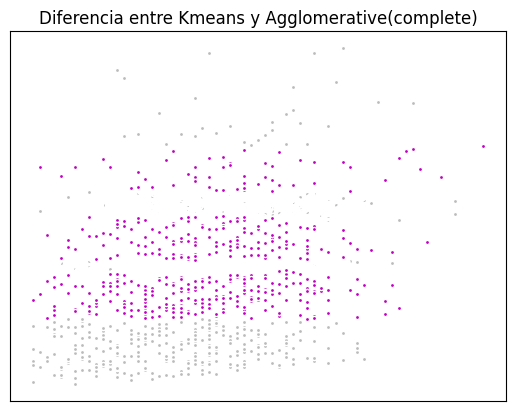

In [261]:
different_algorithms = cluster_labels != complete_labels
    
identical = np.logical_not(different_algorithms)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different_algorithms, 0], train.iloc[different_algorithms, 1], "w", markerfacecolor="m", marker=".")
plt.title("Diferencia entre Kmeans y Agglomerative(complete)")
plt.xticks(())
plt.yticks(())

plt.show()

In [262]:
print("Centros KMeans:")
for i, c in enumerate(cluster_centers):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros Aglomerative(Complete):")
for i, c in enumerate(complete_centers):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print(f"¿Cuántos marcados como 'different'?: {different_algorithms.sum()} de {len(cluster_labels)}")


Centros KMeans:
  KM 0: total_time=83.0
  KM 1: total_time=183.9
  KM 2: total_time=289.1
  KM 3: total_time=425.6

Centros Aglomerative(Complete):
  MBK 0: total_time=125.4
  MBK 1: total_time=260.6
  MBK 2: total_time=361.0
  MBK 3: total_time=493.5
¿Cuántos marcados como 'different'?: 486 de 944


Centros MiniBatchKMeans (ordenados por time_minutes):
 [[ 29.59589041  80.15068493]
 [ 33.8990228  175.17915309]
 [ 36.52589641 279.61752988]
 [ 39.82978723 422.56382979]]
Centros Agglomerative complete (ordenados por time_minutes):
 [[ 31.7677643  125.44020797]
 [ 35.13761468 260.64220183]
 [ 39.93220339 360.95762712]
 [ 40.61290323 493.4516129 ]]


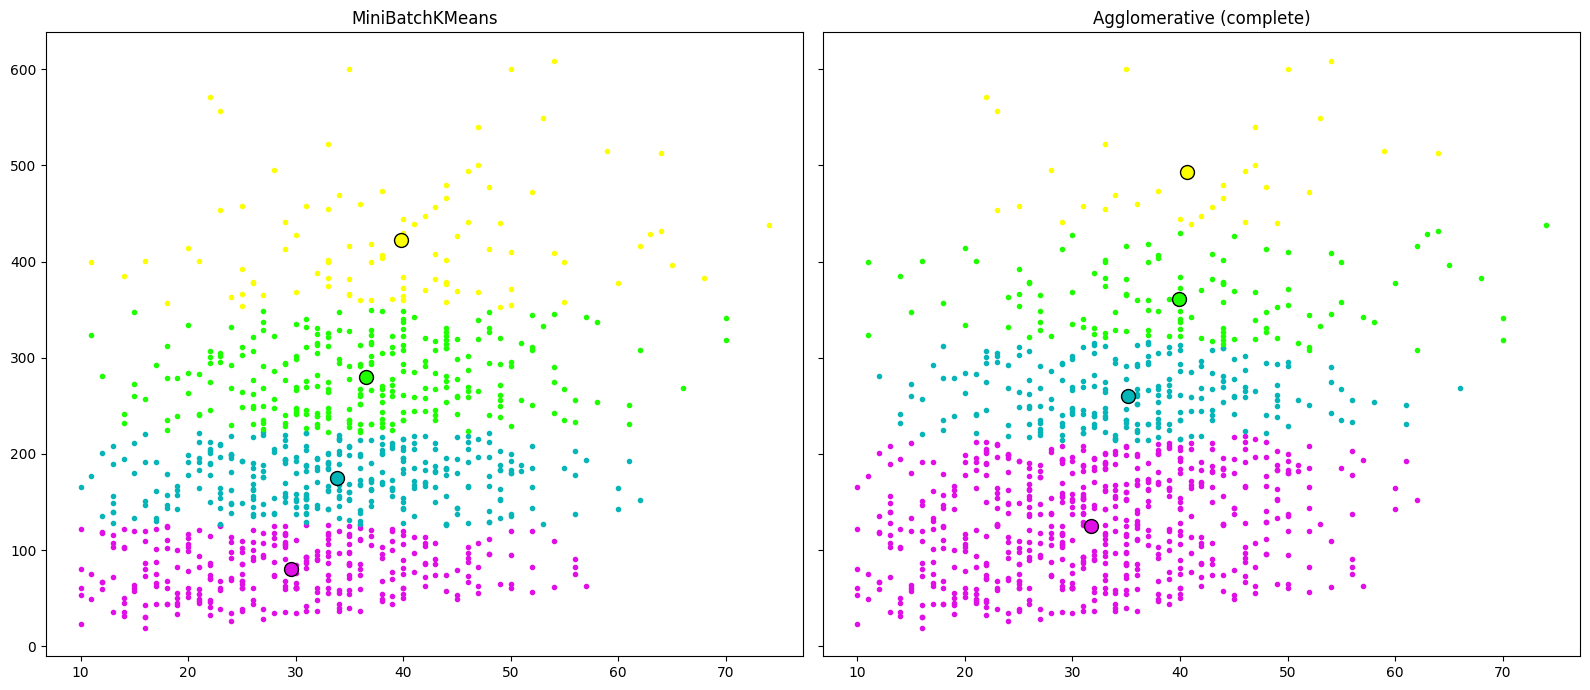

In [263]:
print("Centros MiniBatchKMeans (ordenados por time_minutes):\n", mincluster_centers)
print("Centros Agglomerative complete (ordenados por time_minutes):\n", complete_centers)

colors = ["#DF0FE6", "#06B5B8", "#1EFF00", "#FBFF00"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

for k, col in zip(range(4), colors):
    axes[0].scatter(train.iloc[mincluster_labels == k, 0], train.iloc[mincluster_labels == k, 1], color=col, marker=".")
    axes[0].scatter(mincluster_centers[k, 0], mincluster_centers[k, 1], color=col, edgecolor="k", s=100)
axes[0].set_title("MiniBatchKMeans")

for k, col in zip(range(4), colors):
    axes[1].scatter(train.iloc[complete_labels == k, 0], train.iloc[complete_labels == k, 1], color=col, marker=".")
    axes[1].scatter(complete_centers[k, 0], complete_centers[k, 1], color=col, edgecolor="k", s=100)
axes[1].set_title("Agglomerative (complete)")

plt.tight_layout()
plt.show()

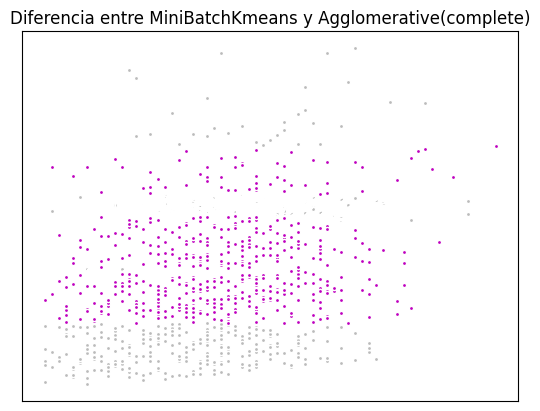

In [264]:
different_algorithms = mincluster_labels != complete_labels
    
identical = np.logical_not(different_algorithms)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different_algorithms, 0], train.iloc[different_algorithms, 1], "w", markerfacecolor="m", marker=".")
plt.title("Diferencia entre MiniBatchKmeans y Agglomerative(complete)")
plt.xticks(())
plt.yticks(())

plt.show()

In [265]:
print("Centros MiniBatchKMeans (originales):")
for i, c in enumerate(mincluster_centers):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros Aglomerative(Complete):")
for i, c in enumerate(complete_centers):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print(f"¿Cuántos marcados como 'different'?: {different_algorithms.sum()} de {len(mincluster_labels)}")


Centros MiniBatchKMeans (originales):
  KM 0: total_time=80.2
  KM 1: total_time=175.2
  KM 2: total_time=279.6
  KM 3: total_time=422.6

Centros Aglomerative(Complete):
  MBK 0: total_time=125.4
  MBK 1: total_time=260.6
  MBK 2: total_time=361.0
  MBK 3: total_time=493.5
¿Cuántos marcados como 'different'?: 544 de 944


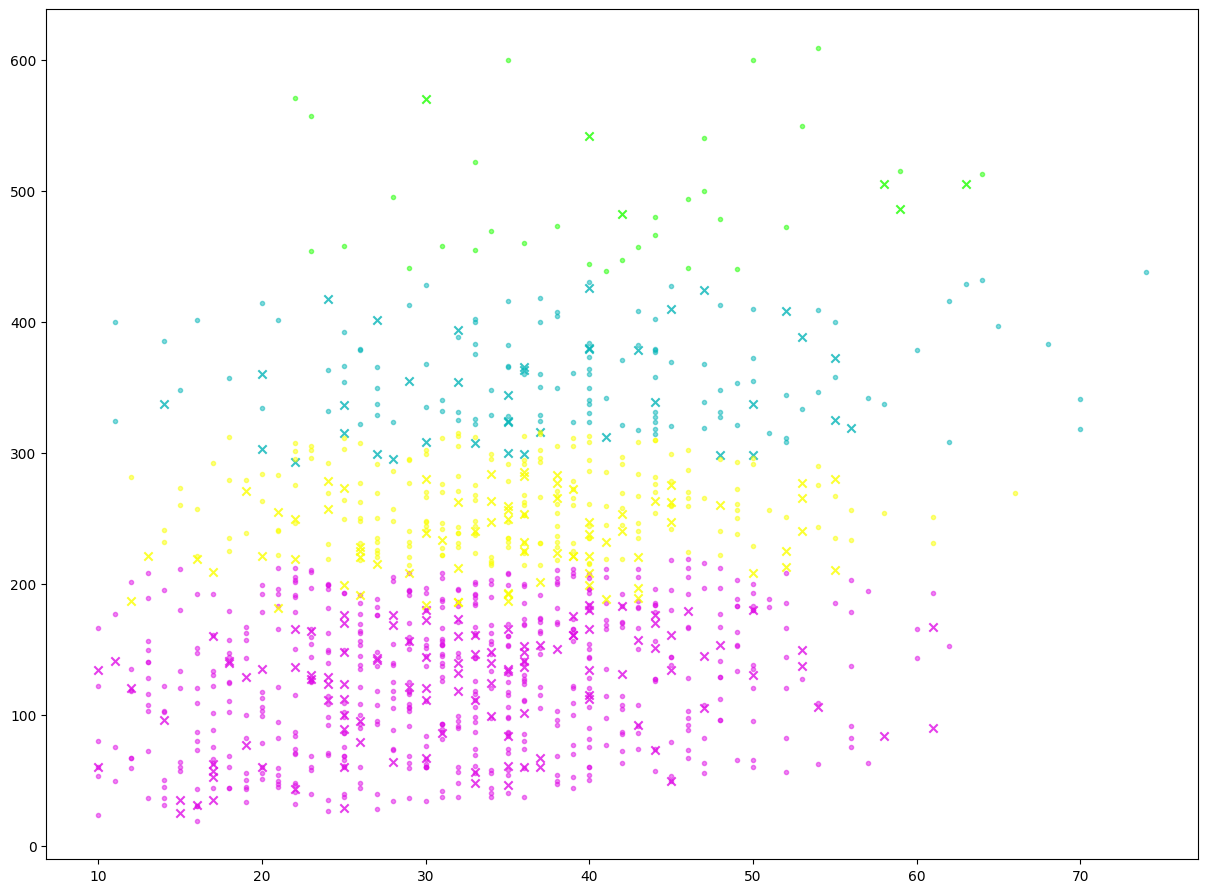

In [266]:
y_pred_complete = modelHier2.labels_.astype(int)
y_pred_test_complete = modelHier2.fit_predict(test)

fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members_train = y_pred_complete == k 
    my_members_test = y_pred_test_complete == k
    plt.scatter(train.iloc[my_members_train, 0], train.iloc[my_members_train, 1], alpha = 0.5, color=col, marker=".")
    plt.scatter(test.iloc[my_members_test, 0], test.iloc[my_members_test, 1],  alpha = 0.8, color=col, marker="x")

plt.show()